<a href="https://colab.research.google.com/github/imshubhamkore/Lead_Scoring_ML_Model/blob/main/Lead_Scoring_ML_Model.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#  Problem Statement

An education company named X Education sells online courses to industry professionals.


The typical lead conversion rate at X Education is between 30%-40%. The CEO wishes to see the lead conversion rate increase to around 80%.


Develop a lead scoring model using a leads dataset from the past with around 9000 data points and various attributes such as Lead Source, Total Time Spent on Website, Total Visits, Last Activity, etc.

In [100]:
#Impor Libraries
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, roc_auc_score,RocCurveDisplay

import warnings
warnings.filterwarnings('ignore')

In [101]:
df=pd.read_csv('Leads.csv')
df.head()

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
0,7927b2df-8bba-4d29-b9a2-b6e0beafe620,660737,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Modified
1,2a272436-5132-4136-86fa-dcc88c88f482,660728,API,Organic Search,No,No,0,5.0,674,2.5,...,No,Select,Select,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
2,8cc8c611-a219-4f35-ad23-fdfd2656bd8a,660727,Landing Page Submission,Direct Traffic,No,No,1,2.0,1532,2.0,...,No,Potential Lead,Mumbai,02.Medium,01.High,14.0,20.0,No,Yes,Email Opened
3,0cc2df48-7cf4-4e39-9de9-19797f9b38cc,660719,Landing Page Submission,Direct Traffic,No,No,0,1.0,305,1.0,...,No,Select,Mumbai,02.Medium,01.High,13.0,17.0,No,No,Modified
4,3256f628-e534-4826-9d63-4a8b88782852,660681,Landing Page Submission,Google,No,No,1,2.0,1428,1.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,No,Modified


## Data Preprocessing

This section seeks to impute null or incorrect values in the dataset and ensure all dataset features are of the correct data type.

In [102]:
#Sample view of the dataset
df.sample(5)

,Prospect ID,Lead Number,Lead Origin,Lead Source,Do Not Email,Do Not Call,Converted,TotalVisits,Total Time Spent on Website,Page Views Per Visit,...,Get updates on DM Content,Lead Profile,City,Asymmetrique Activity Index,Asymmetrique Profile Index,Asymmetrique Activity Score,Asymmetrique Profile Score,I agree to pay the amount through cheque,A free copy of Mastering The Interview,Last Notable Activity
8606,a5254b6e-8953-42ce-8904-dc5e38a1732f,584061,Landing Page Submission,Organic Search,No,No,0,4.0,114,4.0,...,No,Select,Mumbai,02.Medium,01.High,15.0,18.0,No,Yes,Modified
4825,e5a5dfbc-db09-41d6-aa39-aa6a2369c819,613689,API,Google,No,No,1,3.0,815,1.5,...,No,NaN,NaN,NaN,NaN,NaN,NaN,No,No,SMS Sent
7152,3646a745-15fa-47db-aad5-894953da468c,594636,API,Olark Chat,No,No,0,0.0,0,0.0,...,No,NaN,NaN,03.Low,02.Medium,12.0,15.0,No,No,Modified
9039,e1ae760b-29d5-4916-9c76-b09d0d277c8e,581115,API,Google,No,No,1,2.0,1171,1.0,...,No,NaN,NaN,02.Medium,02.Medium,15.0,15.0,No,No,Email Opened
4095,6b934d40-c14e-48ab-ac16-e1cc40538084,620635,Landing Page Submission,Direct Traffic,Yes,No,0,1.0,328,1.0,...,No,Select,Other Cities of Maharashtra,NaN,NaN,NaN,NaN,No,No,Modified


In [103]:
#Examine current data types and count of non-null entries by feature
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 37 columns):
 #   Column                                         Non-Null Count  Dtype  
---  ------                                         --------------  -----  
 0   Prospect ID                                    9240 non-null   object 
 1   Lead Number                                    9240 non-null   int64  
 2   Lead Origin                                    9240 non-null   object 
 3   Lead Source                                    9204 non-null   object 
 4   Do Not Email                                   9240 non-null   object 
 5   Do Not Call                                    9240 non-null   object 
 6   Converted                                      9240 non-null   int64  
 7   TotalVisits                                    9103 non-null   float64
 8   Total Time Spent on Website                    9240 non-null   int64  
 9   Page Views Per Visit                           9103 

In [104]:
#Count columns with fewer than 9240 observations in mql
cols_w_nulls = [df[c].isna().max() for c in df.columns]
sum(cols_w_nulls)

17

Of the 37 features in this dataset, 17 have nulls and several more have incorrect data types.

As part of our data preparation, we review each feature one-by-one to identify correct data types and appropriate null handling.

In [105]:
#Drop Prospect ID, we can use Lead Number as the unique ID for each observation
df.drop(columns='Prospect ID', axis=1, inplace=True)

Null Handling: Lead Source
 * Lead Source: The source of the lead. Includes Google, Organic Search, Olark Chat, etc.

Assess the distribution of the feature to determine the preferred null imputation method.

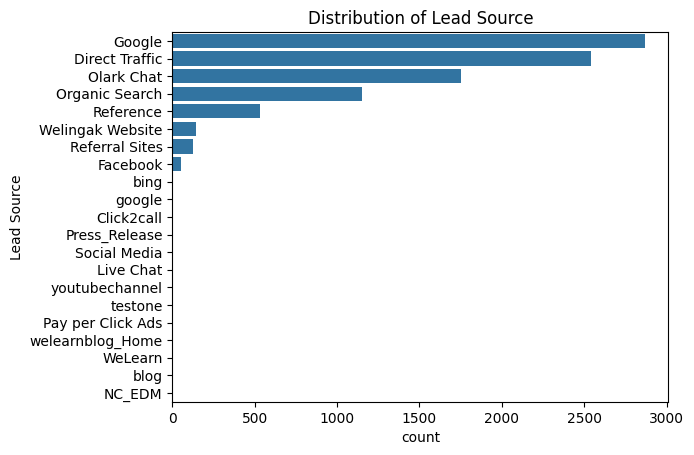

In [106]:
#Plot distribution of Lead Source
sns.countplot(y='Lead Source', data=df, order = df['Lead Source'].value_counts().index)
plt.title('Distribution of Lead Source')
plt.show()

There is no single most common Lead Source which could be used to impute null values. As a result, imputing nulls with a new value "Unknown" would be the preferred null imputation method.

In [107]:
#Impute nulls with "Unknown"
df['Lead Source'] = df['Lead Source'].fillna('Unknown')

Data Type Correction: Do Not Email, Do Not Call, Converted
 * Do Not Email: An indicator variable selected by the customer wherein they select whether of not they want to be emailed about the course or not.
 * Do Not Call: An indicator variable selected by the customer wherein they select whether of not they want to be called about the course or not.
 * Converted: The target variable. Indicates whether a lead has been successfully converted or not.

These features will be easier to manipulate, interpret, and use in a model by converting them to boolean values.

In [108]:
#Convert Do Not Email, Do Not Call, Converted to boolean values
for c in ['Do Not Email', 'Do Not Call', 'Converted']:
    df[c] = df[c].replace('Yes',1)
    df[c] = df[c].replace('No',0)
    df[c] = df[c].astype(bool)

Null Handling: TotalVisits & Page Views Per Visit
 * TotalVisit: The total number of visits made by the customer on the website.
 * Page Views Per Visit: The total number of visits made by the customer on the website.

We assess the distribution of each of these features to determine the best imputation method.

In [109]:
#Examine distribution of Total Visits
print(df['TotalVisits'].describe())

count    9103.000000
mean        3.445238
std         4.854853
min         0.000000
25%         1.000000
50%         3.000000
75%         5.000000
max       251.000000
Name: TotalVisits, dtype: float64


In [110]:
#Examine distribution of page views per visit
print(df['Page Views Per Visit'].describe())

count    9103.000000
mean        2.362820
std         2.161418
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        55.000000
Name: Page Views Per Visit, dtype: float64


The distributions for both these features is severely left-skewed, suggesting that median imputation would be best suited to handle nulls.

In addition, TotalVisits should be an integer, not a float.

In [111]:
#Impute nulls in both features with median value of the feature
df['TotalVisits'] = df['TotalVisits'].fillna(df['TotalVisits'].median())
df['Page Views Per Visit'] = df['Page Views Per Visit'].fillna(df['Page Views Per Visit'].median())

#Convert data type to int
df['TotalVisits'] = df['TotalVisits'].astype('int')

Null Handling: Last Activity
 * Last Activity: Last activity performed by the customer. Includes Email Opened, Olark Chat Conversation, etc.

Assess the distribution of the feature to determine best null imputation method.

Text(0.5, 1.0, 'Distribution of Last Activity')

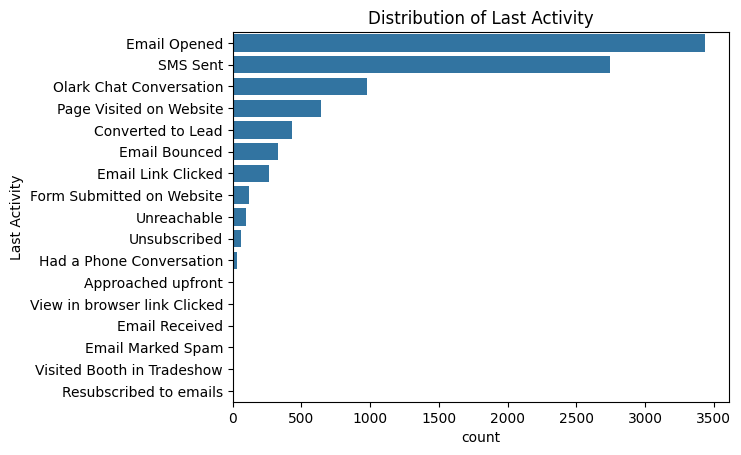

In [112]:
#Plot distribution of leads by Last Activity
sns.countplot(y='Last Activity', data=df, order = df['Last Activity'].value_counts().index)
plt.title('Distribution of Last Activity')

No category for Last Activity stands out as the likely value for nulls in this feature. As a result, imputing nulls with a new category called "Null" is best.

In [113]:
#Impute nulls with new category
df['Last Activity'] = df['Last Activity'].fillna('Null')

Null Handling: Country
* Country: The country of the customer.

Assess the distribution of the feature to identify the appropriate null handling method.

Text(0.5, 1.0, 'Distribution of Leads by Country')

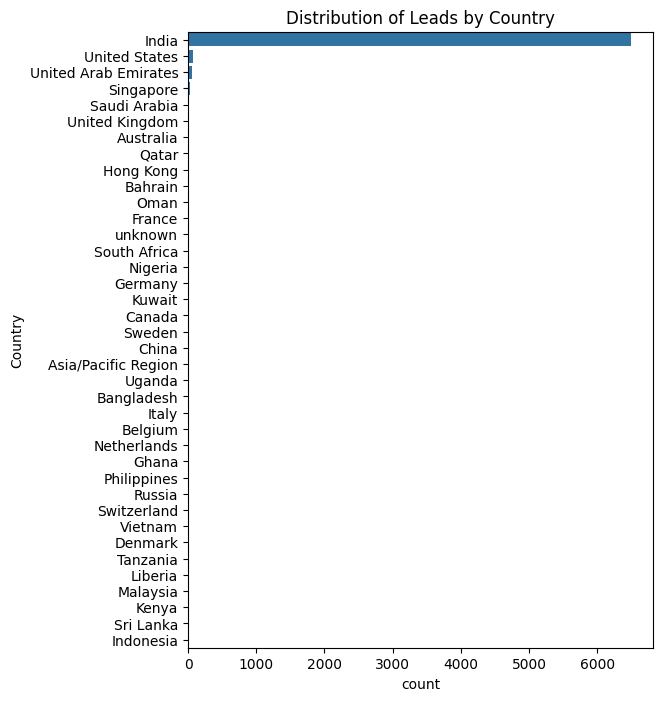

In [114]:
#Plot distribution of Leads by Country
plt.figure(figsize=(6,8))
sns.countplot(y='Country', data=df, order = df['Country'].value_counts().index)
plt.title('Distribution of Leads by Country')

In [115]:
#Print the percentage of values that are null in the Country feature
print(round(df['Country'].isna().sum()*100/len(df['Country']),2),'% of values in Country are null.')

26.63 % of values in Country are null.


Maybe we can deduce the country a lead is located in from the city they have indicated they are located in.

Text(0.5, 1.0, 'Distribution of Leads by City where Country is null')

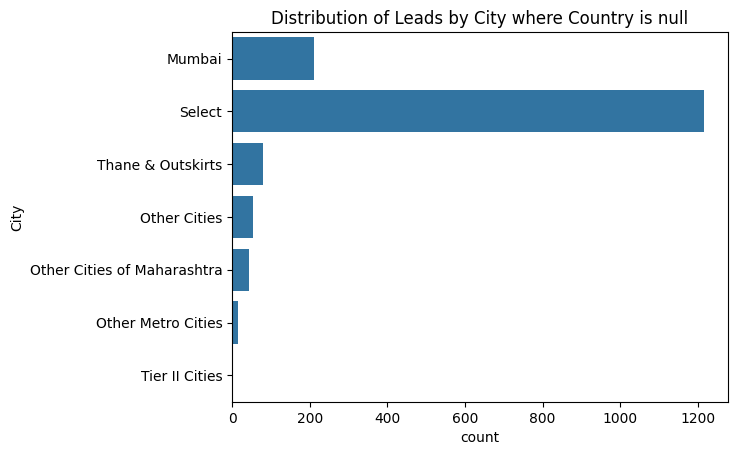

In [116]:
#Plot distribution of City where Country is null
sns.countplot(y='City', data=df[df['Country'].isna()], order = df['City'].value_counts().index)
plt.title('Distribution of Leads by City where Country is null')

For cities that are located in India, we can impute null values in Country as "India". Otherwise, we should impute nulls in Country as "Unknown"

In [117]:
#Impute nulls in Country based on Country
india_cities = ['Mumbai','Other Cities of Maharashtra','Thane & Outskirts']

for i in df[df['Country'].isnull()].index:
    if df.loc[i,'City'] in india_cities:
        df.loc[i,'Country'] = 'India'
    else:
        df.loc[i,'Country'] = 'Unknown'

Data Type Correction: Search, Magazine, Newspaper Article, X Education Forums, Newspaper, Digital Advertisement
 * Search: Indicating whether the customer had seen the ad in any of the listed items (i.e. during a web search).
 * Magazine: Indicating whether the customer had seen the ad in any of the listed items (i.e. in a magazine).
 * Newspaper Article: Indicating whether the customer had seen the ad in any of the listed items (i.e. in a newspaper article).
 * X Education Forums: Indicating whether the customer had seen the ad in any of the listed items (i.e. in a X Education forum).
 * Newspaper: Indicating whether the customer had seen the ad in any of the listed items (i.e. in a newspaper).
 * Digital Advertisement: Indicating whether the customer had seen the ad in any of the listed items (i.e. in a digital ad).

These features will be easier to manipulate, interpret, and use in a model by converting them to boolean values.

In [118]:
#Convert yes/no field to boolean
for c in ['Search', 'Magazine', 'Newspaper Article', 'X Education Forums', 'Newspaper', 'Digital Advertisement']:
    df[c] = df[c].replace('Yes',1)
    df[c] = df[c].replace('No',0)
    df[c] = df[c].astype(bool)

Data Type Correction: Through Recommendations, Receive More Updates About Our Courses
 * Through Recommendations: Indicates whether the customer came in through recommendations.
 * Receive More Updates About Our Courses: Indicates whether the customer chose to receive more updates about the courses.

These features will be easier to manipulate, interpret, and use in a model by converting them to boolean values.

In [119]:
#Convert yes/no field to boolean
for c in ['Through Recommendations', 'Receive More Updates About Our Courses']:
    df[c] = df[c].replace('Yes',1)
    df[c] = df[c].replace('No',0)
    df[c] = df[c].astype(bool)


Null Handling: Specialization, How did you hear about X Education
 * Specialization: The industry domain in which the customer worked before. Includes the level 'Select Specialization' which means the customer had not selected this option while filling the form.
 * How did you hear about X Education: The source from which the customer heard about X Education.
 * What is your current occupation: Indicates whether the customer is a student, umemployed or employed.
 * What matters most to you in choosing a course: An option selected by the customer indicating what is their main motto behind doing this course.

Assess the distribution of these features to determine best null imputation method.

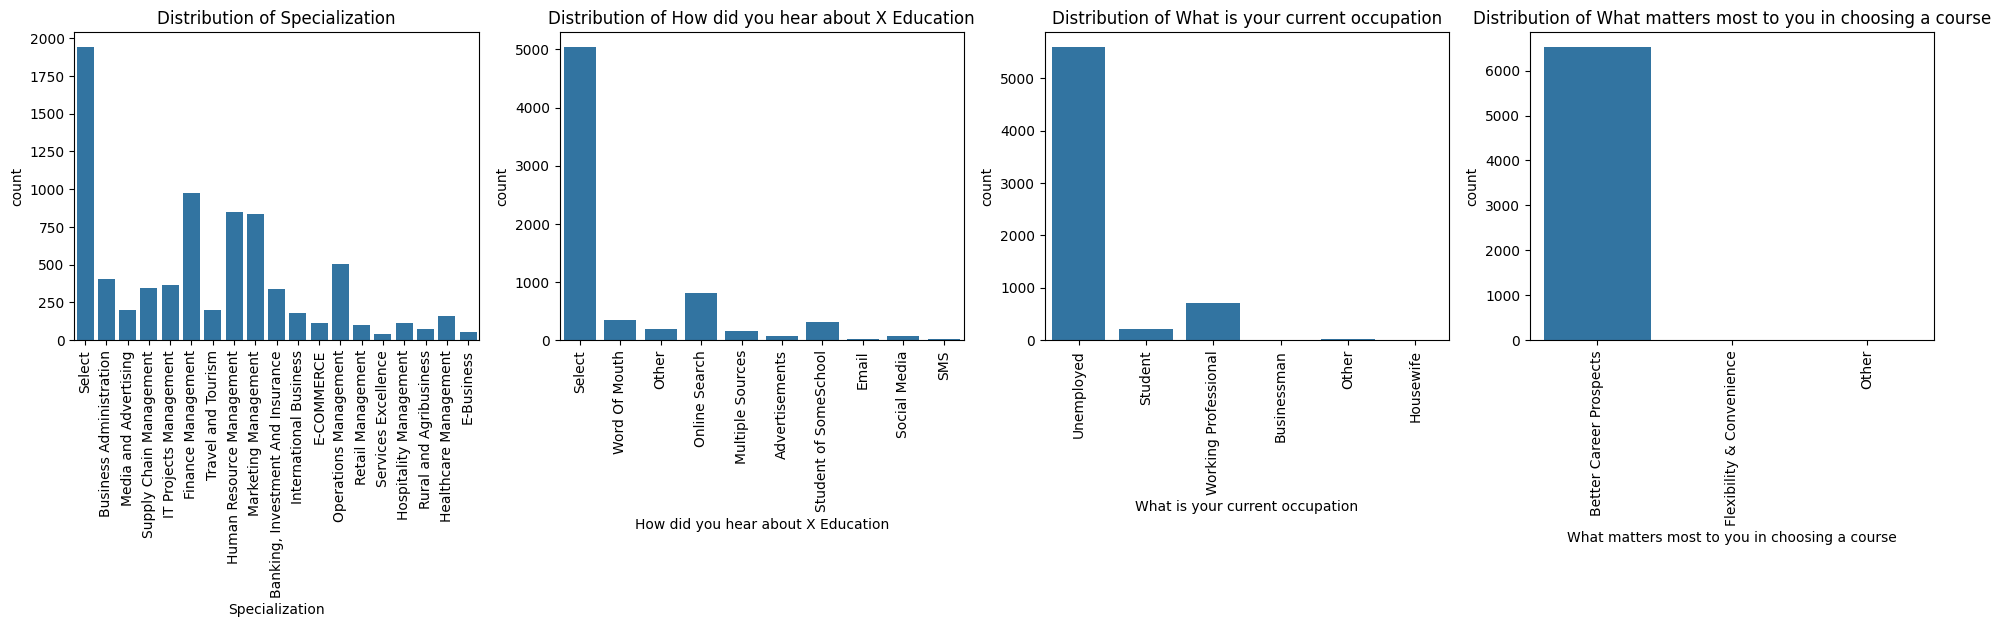

In [120]:
#Examine distribution dropdown fields
dropdown_fields = ['Specialization','How did you hear about X Education','What is your current occupation','What matters most to you in choosing a course']

fig, axes = plt.subplots(nrows=1, ncols=len(dropdown_fields), figsize=(24, 4))

for i in range(len(dropdown_fields)):
    sns.countplot(x=dropdown_fields[i], data=df, ax=axes[i])
    plt.sca(axes[i])
    plt.title("Distribution of " + dropdown_fields[i])
    plt.xticks(rotation=90)

It appears that a large portion of values are "Select", which is equivalent to a null. We can replace these values with nulls.

Since there is no single value for either of these features with which nulls can be imputed, we can impute nulls as "Unknown". We can also check what percentage of values in each feature have nulls

In [121]:
#Impute "Select" with null & print percentage of values in each feature with nulls
for c in dropdown_fields:
    df[c].replace('Select',np.NaN, inplace=True)
    print(round(df[c].isna().sum()*100/len(df[c]),2),'% of values in',c,'are null.')

36.58 % of values in Specialization are null.
78.46 % of values in How did you hear about X Education are null.
29.11 % of values in What is your current occupation are null.
29.32 % of values in What matters most to you in choosing a course are null.


In [122]:
#Impure nulls with "Unknown"
for c in dropdown_fields:
    df[c].fillna('Unknown', inplace=True)

Data Type Correction: Update me on Supply Chain Content, Get updates on DM Content
 * Update me on Supply Chain Content: Indicates whether the customer wants updates on the Supply Chain Content.
 * Get updates on DM Content: Indicates whether the customer wants updates on the DM Content.

These features will be easier to manipulate, interpret, and use in a model by converting them to boolean values.

In [123]:
#Convert yes/no field to boolean
for c in ['Update me on Supply Chain Content', 'Get updates on DM Content']:
    df[c] = df[c].replace('Yes',1)
    df[c] = df[c].replace('No',0)
    df[c] = df[c].astype(bool)

Drop Feature: Tags
 * Tags: Tags assigned to customers indicating the current status of the lead.

Since Tags is determined by the progress of a lead through the marketing funnel, is it likely endogenous to the conversion status of the lead. As a result, this feature should be dropped.

In [124]:
#Drop Tags feature
df.drop(columns='Tags', axis=1, inplace=True)

Drop Feature: Lead Quality
 * Lead Quality: Indicates the quality of lead based on the data and intuition the employee who has been assigned to the lead.

Since Lead Quality is the measure we are looking to replace with the Lead Score, we should not include in our model.

In [125]:
#Drop Lead Quality feature
df.drop(columns='Lead Quality', axis=1, inplace=True)

Null Handling: Lead Profile
 * Lead Profile: A lead level assigned to each customer based on their profile.

Assess the distribution of this feature to determine best null imputation method.

Text(0.5, 1.0, 'Distribution of Leads by Lead Profile')

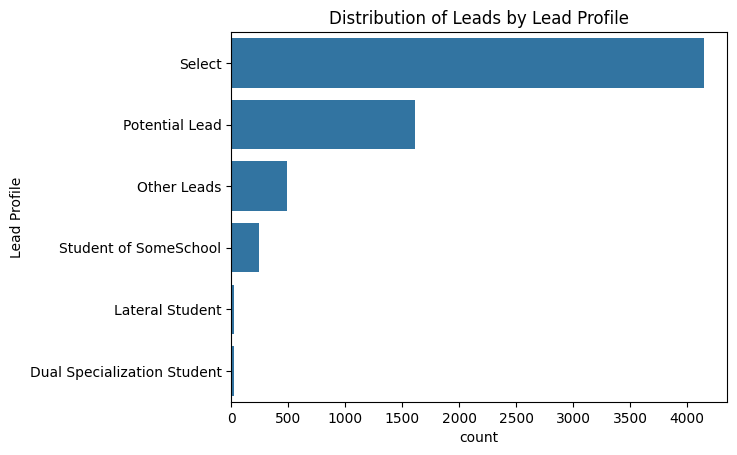

In [126]:
#Plot distribution of Lead Profile
sns.countplot(y='Lead Profile', data=df, order = df['Lead Profile'].value_counts().index)
plt.title('Distribution of Leads by Lead Profile')

A large portion of values are "Select", which is equivalent to a null. There is no single lead profile that stands out as a clear value for null imputation. As a result, nulls should be imputed with the value "Unknown".

In [127]:
#Impute "Select" value with null
df['Lead Profile'].replace('Select', np.NaN, inplace=True)

In [128]:
#Impute nulls with "Unknown"
df['Lead Profile'].fillna('Unknown', inplace=True)

Null Handling: City
 * City: The city of the customer.

Assess the distribution of the feature to determine best null imputation method.

Text(0.5, 1.0, 'Distribution of City')

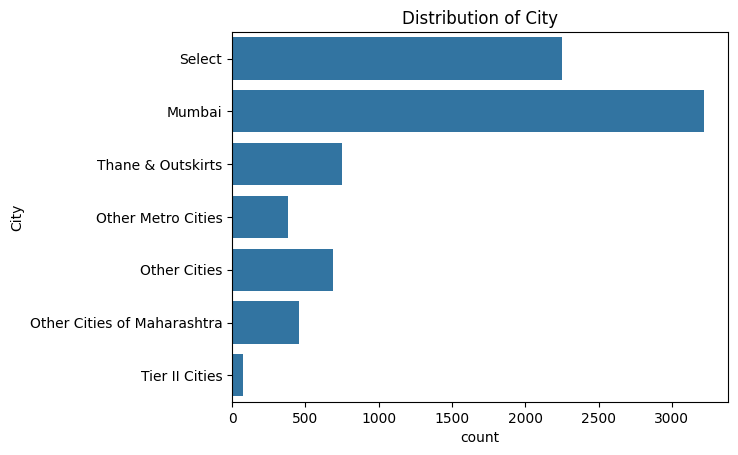

In [129]:
#Examine distribution of City
sns.countplot(y='City', data=df)
plt.title('Distribution of City')

Here again, a large portion of values are "Select", which is equivalent to a null. There is no single city that stands out as a clear value for null imputation. As a result, nulls should be imputed with the value "Unknown".

In [130]:
#Impute "Select" value with null
df['City'].replace('Select', np.NaN, inplace=True)

In [131]:
#Impute nulls with "Unknown"
df['City'].fillna('Unknown', inplace=True)

Data Type Correction: I agree to pay the amount through cheque, A free copy of Mastering The Interview
 * I agree to pay the amount through cheque: Indicates whether the customer has agreed to pay the amount through cheque or not.
 * A free copy of Mastering The Interview: Indicates whether the customer wants a free copy of 'Mastering the Interview' or not.

These features will be easier to manipulate, interpret, and use in a model by converting them to boolean values.

In [132]:
#Convert remaining yes/no fields to boolean values
for c in ['I agree to pay the amount through cheque', 'A free copy of Mastering The Interview']:
    df[c] = df[c].replace('Yes',1)
    df[c] = df[c].replace('No',0)
    df[c] = df[c].astype(bool)

Data Type Correction: Object to Category

Categorical variables with be more easily interpreted by our model if they recorded as such.

In [133]:
#Convert string type fields to category type
for c in df.columns:
    if df[c].dtype=='object': df[c] = df[c].astype('category')

Finally, we can review the dataset to ensure no features contain nulls and all features are of the correct data type.

Asymmetrique Index & Scores
 * Asymmetrique Activity Index: An index and score assigned to each customer based on their activity and their profile.
 * Asymmetrique Profile Index: An index and score assigned to each customer based on their activity and their profile.
 * Asymmetrique Activity Score: An index and score assigned to each customer based on their activity and their profile.
 * Asymmetrique Profile Score: An index and score assigned to each customer based on their activity and their profile.

Assess the distribution of each feature to determine the most appropriate null imputation method.

In [134]:
#Print descriptive statistics of score features
stats_AS = pd.DataFrame(
    {'Asymmetrique Activity Score':df['Asymmetrique Activity Score'].describe(),
    'Asymmetrique Profile Score':df['Asymmetrique Profile Score'].describe()})
stats_AS

,Asymmetrique Activity Score,Asymmetrique Profile Score
count,5022.000000,5022.000000
mean,14.306252,16.344883
std,1.386694,1.811395
min,7.000000,11.000000
25%,14.000000,15.000000
50%,14.000000,16.000000
75%,15.000000,18.000000
max,18.000000,20.000000


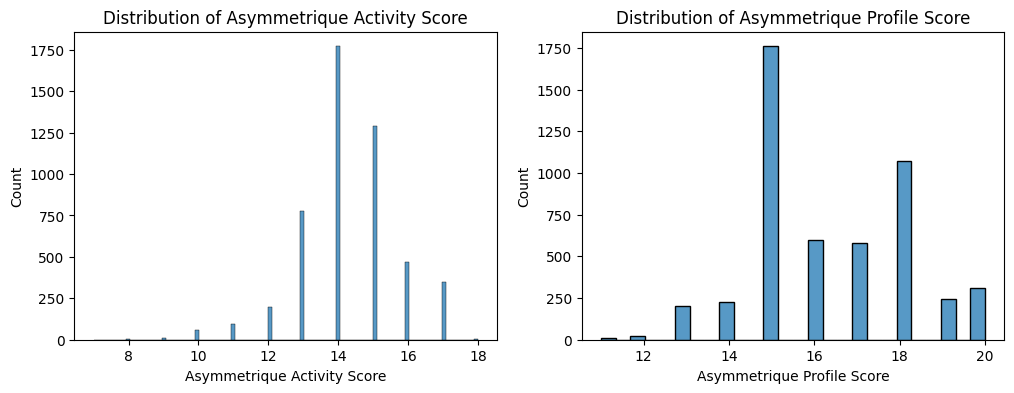

In [135]:
#Plot distribution of Asymmetrique Activity Score & Asymmetrique Profile Score
score_fields = ['Asymmetrique Activity Score','Asymmetrique Profile Score']

fig, axes = plt.subplots(nrows=1, ncols=len(score_fields), figsize=(12, 4))

for i in range(len(score_fields)):
    sns.histplot(x=score_fields[i], data=df, ax=axes[i])
    plt.sca(axes[i])
    plt.title("Distribution of " + score_fields[i])

Both distributions are slight left-skewed. As a result, median imputation may be more appropriate than mean imputation.

In [136]:
#Impute nulls with median
for f in score_fields:
    df[f].fillna(df[f].median(), inplace=True)

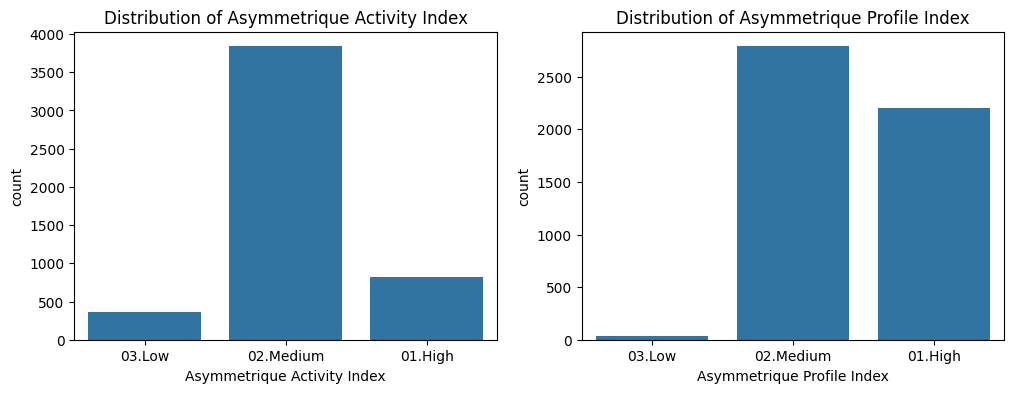

In [137]:
#Plot distribution of Asymmetrique Activity Index & Asymmetrique Profile Index
index_fields = ['Asymmetrique Activity Index','Asymmetrique Profile Index']

fig, axes = plt.subplots(nrows=1, ncols=len(index_fields), figsize=(12, 4))

for i in range(len(index_fields)):
    sns.countplot(x=index_fields[i], data=df, ax=axes[i], order=['03.Low','02.Medium','01.High'])
    plt.sca(axes[i])
    plt.title("Distribution of " + index_fields[i])

It appears that the index features may simply be bucketed according to the Asymmetrique Score, in which case both these index features are redundant. We can confirm this by observing the mean Asymmetrique Score by Asymetrique Index.

In [138]:
#Group by Asymmetrique Activity Index
grouped_by_activity_index = df.groupby('Asymmetrique Activity Index').agg({'Asymmetrique Activity Score':'mean'})
grouped_by_activity_index

,Asymmetrique Activity Score
Asymmetrique Activity Index,
01.High,16.437272
02.Medium,14.134931
03.Low,11.290055


In [139]:
#Group by Asymmetrique Profile Index
grouped_by_profile_index = df.groupby('Asymmetrique Profile Index').agg({'Asymmetrique Profile Score':'mean'})
grouped_by_profile_index

,Asymmetrique Profile Score
Asymmetrique Profile Index,
01.High,18.128007
02.Medium,14.987446
03.Low,11.709677


As can be seen above, Asymmetrique Activity/Profile Index values appear to simply bucket Asymmetrique Activity/Profile Scores. As a result, the index features are redundant and can be dropped.

In [140]:
#Drop Asymmetrique Index columns
df.drop(columns=['Asymmetrique Activity Index','Asymmetrique Profile Index'], axis=1, inplace=True)

We can now review the remaining features in the dataset to ensure none of any nulls and that all data types are correct.

In [141]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9240 entries, 0 to 9239
Data columns (total 32 columns):
 #   Column                                         Non-Null Count  Dtype   
---  ------                                         --------------  -----   
 0   Lead Number                                    9240 non-null   int64   
 1   Lead Origin                                    9240 non-null   category
 2   Lead Source                                    9240 non-null   category
 3   Do Not Email                                   9240 non-null   bool    
 4   Do Not Call                                    9240 non-null   bool    
 5   Converted                                      9240 non-null   bool    
 6   TotalVisits                                    9240 non-null   int64   
 7   Total Time Spent on Website                    9240 non-null   int64   
 8   Page Views Per Visit                           9240 non-null   float64 
 9   Last Activity                            

## Exploratory Data Analysis

This section seeks to explore the relationship between each feature of the dataset and the target variable, Converted.

To facilitate this process, we define two functions that allow rapid comparison of distribution by Converted.

In [142]:
#Create functions to facilitate EDA

def count_by_converted(feature, target='Converted'):
    #Plot a seaborn countplot for the feature by Converted & add a relevant title
    sns.countplot(y=feature, data=df, hue=target, order = df[feature].value_counts().index)
    plt.title("Distribution of " + feature + " by Converted")
    plt.show()

In [143]:
def confusionmatrix_by_converted(feature, target='Converted'):
    #Plot confusion matrix heatmap of a boolean feature vs. Converted & add relevant labels
    cm=confusion_matrix(df[feature], df[target])
    sns.heatmap(cm, annot=True, fmt='', xticklabels=['No','Yes'], yticklabels=['No','Yes'], cmap='Purples')
    plt.title(feature + " vs. " + target + " Confusion Matrix")
    plt.xlabel(target)
    plt.ylabel(feature)
    plt.show()

In [144]:
#Calculate the conversion rate of leads across the dataset
round(df['Converted'].mean()*100,2)

38.54

The average lead conversion rate across this dataset is 38.54%.

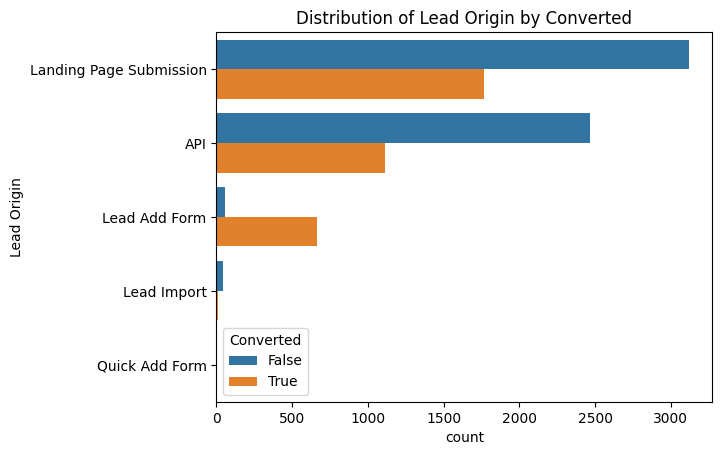

In [145]:
#Plot distribution of Lead Origin by Converted
count_by_converted('Lead Origin')

### Observations

* Significantly more leads convert when they originate from the "Lead Add Form".

* The lead conversion rate appears slighly higher among leads originating from "Landing Page Submission" than from "API".

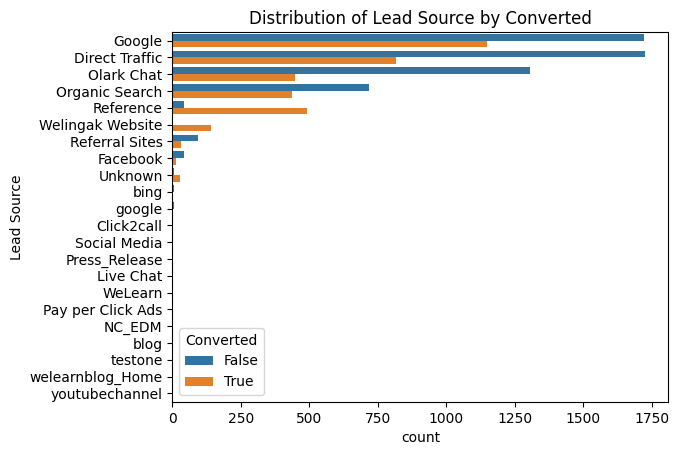

In [146]:
#Plot distribution of Lead Source by Converted
count_by_converted('Lead Source')

### Observations

* Conversion rate appears to be highest for leads that come from the Wellingak Website or that are referred.
* **It is possible that increasing the number of leads that are referred and that come from the Willingak Website would increase the overall conversion rate.**
* While Google and Direct Traffic are the source for a similar number of leads, the conversion rate appears higher among leads that come from Google.
* Fewer leads have Organic Search as a source than Google, but leads coming from both these sources appear to have a similar conversion rate.

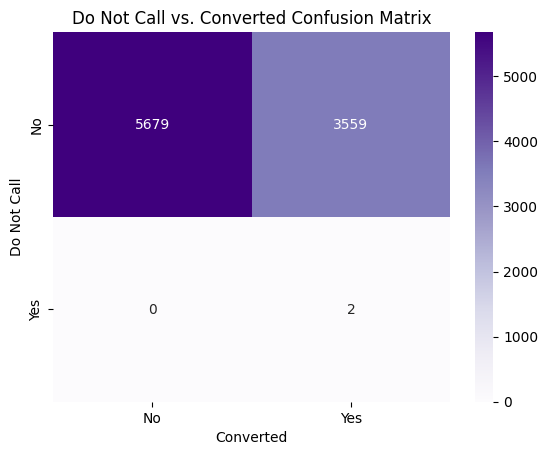

In [147]:
#Plot confusion matrix of Do Not Call against Converted
confusionmatrix_by_converted('Do Not Call')

### Observations

* The vast majority of leads indicate "No" under Do Not Call, suggesting that the sales team is free to contact them by phone.
* The conversion rate among leads that indicate "No" under Do Not Call is 38.52%.
* While very few leads have a "Yes" under Do Not Call, the conversion rate among these appears to be 100%.

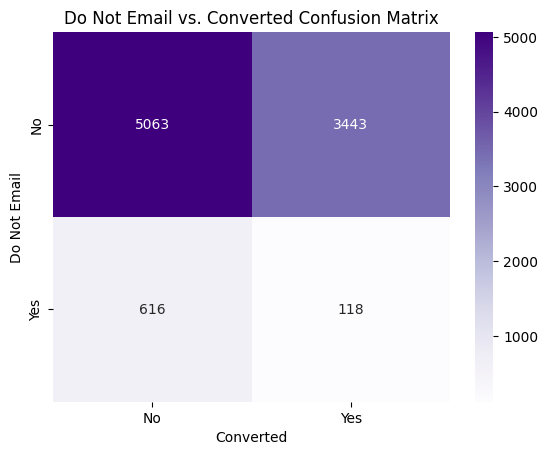

In [148]:
#Plot confusion matrix of Do Not Email against Converted
confusionmatrix_by_converted('Do Not Email')

### Observations

* Here again, the vast majority of leads indicate "No" under Do Not Email, suggesting that the sales team is free to contact them by email.
* The conversion rate among leads that indicate "No" under Do Not Call is 40.47%.
* Very few leads have a "Yes" under Do Not Call (7.94%). The conversion rate among these is to be 16.07%, more than half the conversion rate of leads that are open to receiving emails.

In [149]:
#Get descriptive statistics on TotalVisits by Converted
stats_TV = pd.DataFrame(
    {'TotalVisits_Overall':df['TotalVisits'].describe(),
    'TotalVisits_Converted':df[df['Converted']==True]['TotalVisits'].describe(),
    'TotalVisits_NotConverted':df[df['Converted']==False]['TotalVisits'].describe()})
stats_TV


,TotalVisits_Overall,TotalVisits_Converted,TotalVisits_NotConverted
count,9240.000000,3561.000000,5679.000000
mean,3.438636,3.615838,3.327522
std,4.819024,5.486307,4.345521
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000
50%,3.000000,3.000000,3.000000
75%,5.000000,5.000000,4.000000
max,251.000000,251.000000,141.000000


### Observations

* On average, leads that convert appear to visit the website slightly more than leads that do not convert

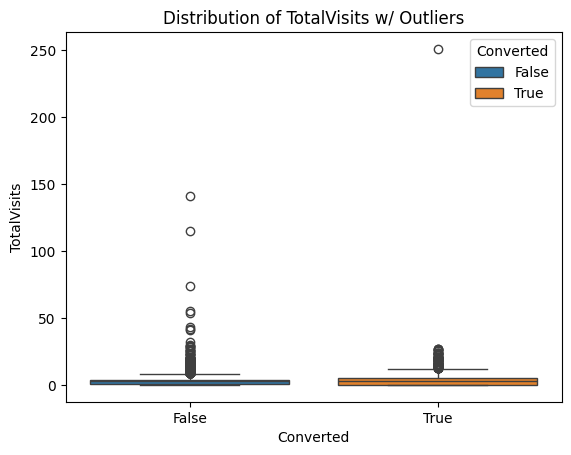

In [150]:
#Plot boxplots for distribution of TotalVisits by Converted
sns.boxplot(y='TotalVisits', data=df, x='Converted', hue='Converted')
plt.title("Distribution of TotalVisits w/ Outliers")
plt.show()

This distribution is difficult to visualize given the number of outliers. To better visualize the distribution of Total visits, we can produce the same plot by removing leads with TotalVisits > 50.

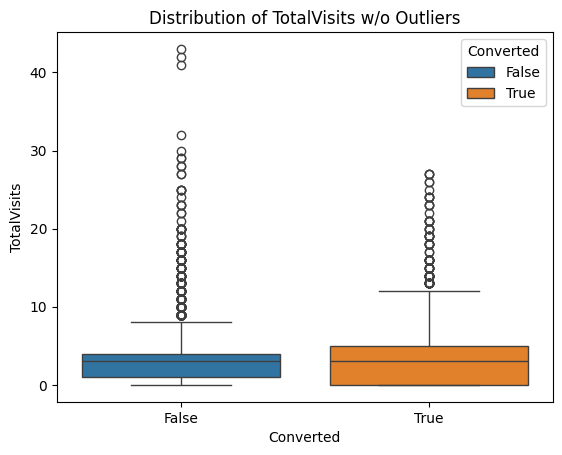

In [151]:
#Remove outliers (TotalVisits > 50) and plot boxplots for distribution of TotalVisits by Converted
sns.boxplot(y='TotalVisits', data=df[df['TotalVisits']<=50], x='Converted', hue='Converted')
plt.title("Distribution of TotalVisits w/o Outliers")
plt.show()

### Observations

In addition to visiting the website more often, leads that convert appear to show a higher spread and IQR than leads that do not convert.

In [152]:
#Get descriptive statistics on Total Time Spent on Website by Converted
stats_TT = pd.DataFrame(
    {'TotalTime_Overall':df['Total Time Spent on Website'].describe(),
    'TotalTime_Converted':df[df['Converted']==True]['Total Time Spent on Website'].describe(),
    'TotalTime_NotConverted':df[df['Converted']==False]['Total Time Spent on Website'].describe()})
stats_TT

,TotalTime_Overall,TotalTime_Converted,TotalTime_NotConverted
count,9240.000000,3561.000000,5679.000000
mean,487.698268,738.546757,330.404473
std,548.021466,615.656010,432.231915
min,0.000000,0.000000,0.000000
25%,12.000000,0.000000,16.000000
50%,248.000000,832.000000,179.000000
75%,936.000000,1268.000000,393.000000
max,2272.000000,2253.000000,2272.000000


### Observations

On average, leads that convert appear to spent more than double the time that leads that do not convert on the website.

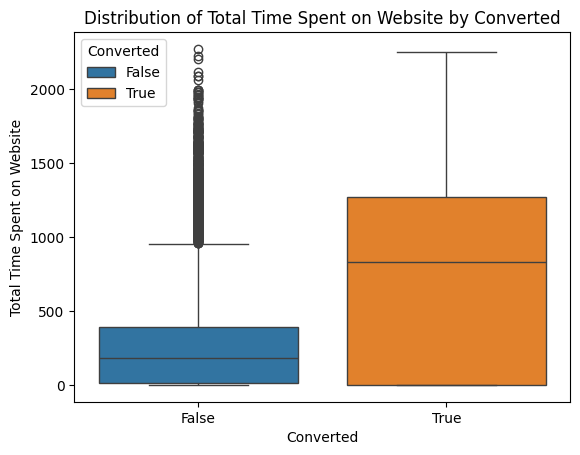

In [153]:
#Plot boxplots for distribution of Total Time Spent on Website by Converted
sns.boxplot(y='Total Time Spent on Website', data=df, x='Converted', hue='Converted')
plt.title("Distribution of Total Time Spent on Website by Converted")
plt.show()

### Observations

* The IQR of Total Time Spent on Website for leads that convert is much higher than for leads that do not convert.
* **It is possible that driving leads to spend more time on the website would increase the overall conversion rate.**

In [154]:
#Get descriptive statistics for Page Views Per Visit by Converted
stats_PV = pd.DataFrame(
    {'TotalTime_Overall':df['Page Views Per Visit'].describe(),
    'TotalTime_Converted':df[df['Converted']==True]['Page Views Per Visit'].describe(),
    'TotalTime_NotConverted':df[df['Converted']==False]['Page Views Per Visit'].describe()})
stats_PV

,TotalTime_Overall,TotalTime_Converted,TotalTime_NotConverted
count,9240.000000,3561.000000,5679.000000
mean,2.357440,2.343707,2.366052
std,2.145781,2.109825,2.168163
min,0.000000,0.000000,0.000000
25%,1.000000,0.000000,1.000000
50%,2.000000,2.000000,2.000000
75%,3.000000,3.330000,3.000000
max,55.000000,24.000000,55.000000


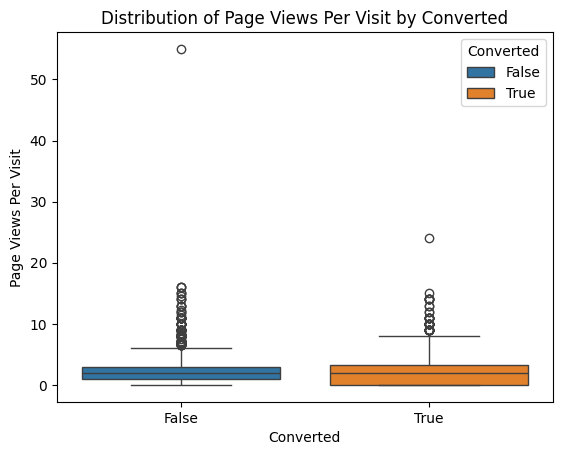

In [155]:
#Plot boxplots for distribution of Page Views Per Visit by Converted
sns.boxplot(y='Page Views Per Visit', data=df, x='Converted', hue='Converted')
plt.title("Distribution of Page Views Per Visit by Converted")
plt.show()

### Observations

* All leads appear to view a similar number of pages per visit on average, regardless of conversion status.
* However, the IQR of Page Views Per Visit is larger for leads that convert, in part because a large portion of leads that convert have an average of 0 page views per visit.
* The outlier that viewed 55 pages per visit on average may not be a lead, but in fact a competitor or an staff member consulting the website

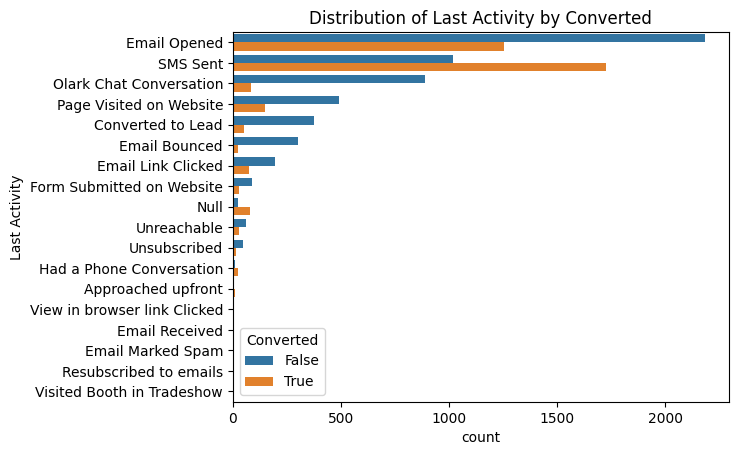

In [156]:
#Plot distribution of Last Activity by Converted
count_by_converted('Last Activity')

### Observations

* The Last Activity with he highest conversion rate is by far SMS Sent.
* **Further investigation is required to determine whether this is a result of th effectiveness of this activity or simply the stage at which it takes place in the lead nurturing process.**

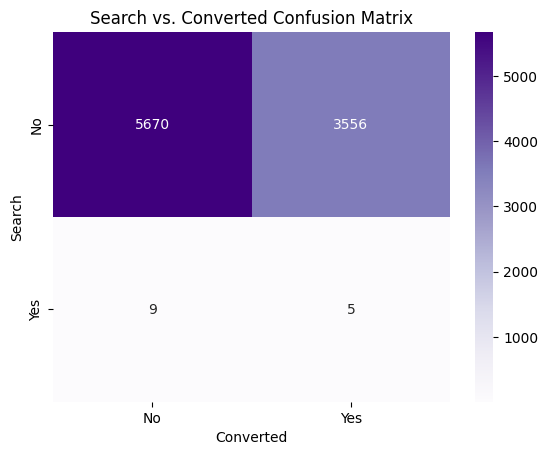

In [157]:
#Plot distribution of Search by Converted
confusionmatrix_by_converted('Search')

### Observations

Very few leads have seen an ad during a web search

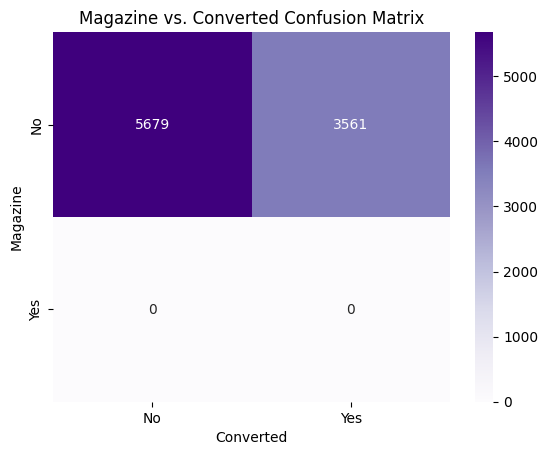

In [158]:
#Plot distribution of Magazine by Converted
confusionmatrix_by_converted('Magazine')

### Observations

* No leads saw an ad in a magazine.

* **X Education may want to reconsider investing in this marketing channel.**

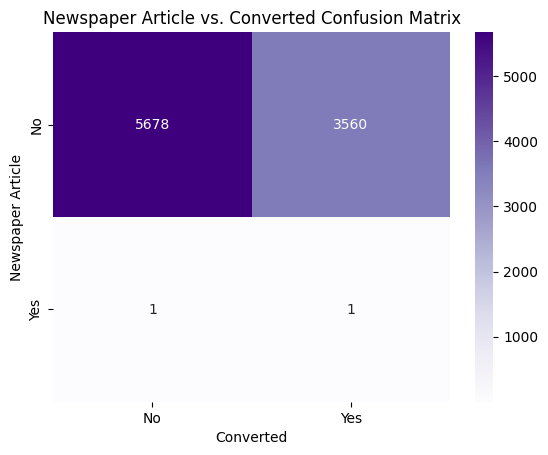

In [159]:
#Plot distribution of Newspaper Article by Converted
confusionmatrix_by_converted('Newspaper Article')

### Observations

* Very few leads saw an ad in a newspaper article.
* **X Education may want to reconsider investing in this marketing channel as well.**

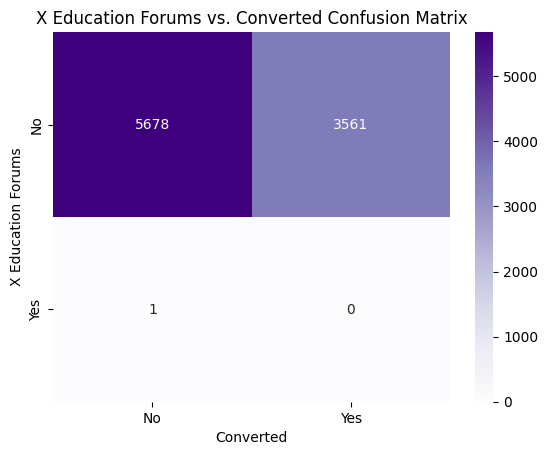

In [160]:
#Plot distribution of X Education Forums by Converted
confusionmatrix_by_converted('X Education Forums')

### Observations

Very few leads saw an ad in an X Education Forum.

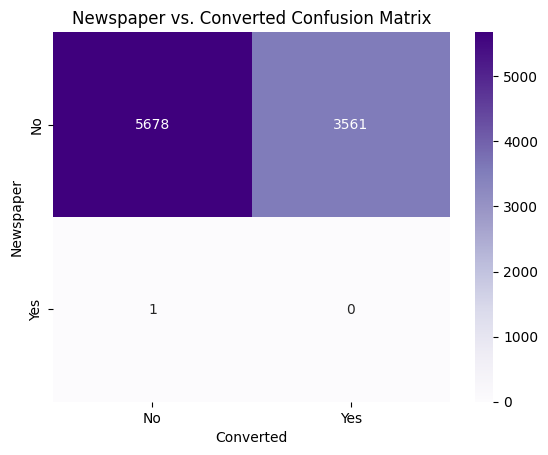

In [161]:
#Plot distribution of Newspaper by Converted
confusionmatrix_by_converted('Newspaper')

### Observations

* Very few leads saw an ad in a newspaper.
* **X Education may want to reconsider investing in this marketing channel as well.**

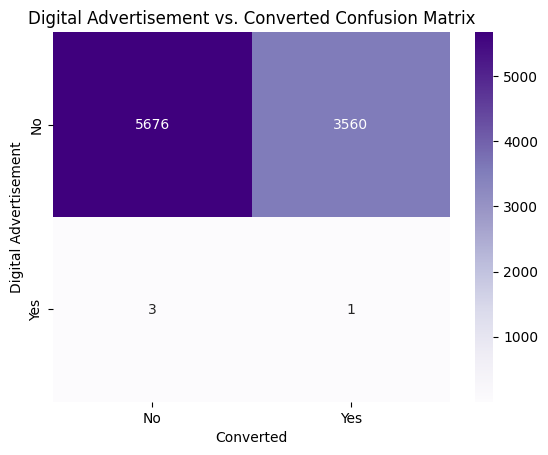

In [162]:
#Plot distribution of Digital Advertisement by Converted
confusionmatrix_by_converted('Digital Advertisement')


## Observations

* Very few leads saw an ad in a Digital Advertisement.

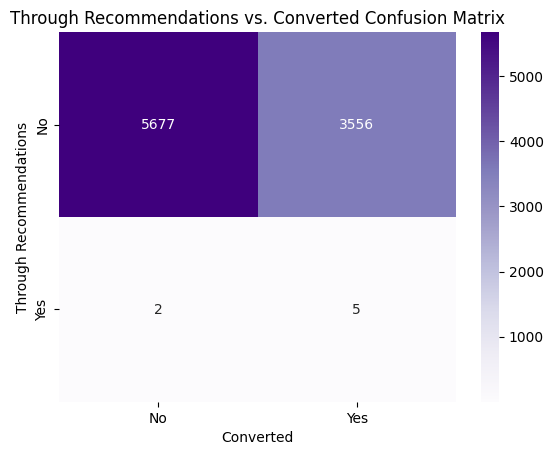

In [163]:
#Plot distribution of Through Recommendations by Converted
confusionmatrix_by_converted('Through Recommendations')

### Observations

* Very few leads appear to have come in through a recommendation.
* This is strange, as more than 500 leads have "Reference" as a Lead Source. Are recommendation and reference different? If so, in what way?

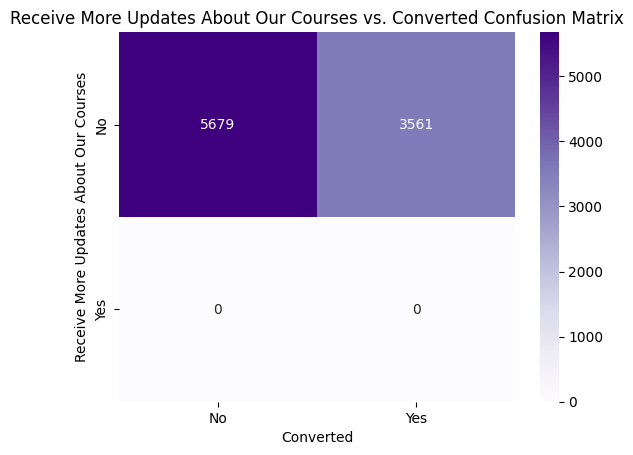

In [164]:
#Plot distribution of Receive More Updates About Our Courses by Converted
confusionmatrix_by_converted('Receive More Updates About Our Courses')

### Observations

* Not a single lead indicated that they wanted to receive more updates on X Education courses.
* If this is not a data error, it should be a point of concern for the organization.

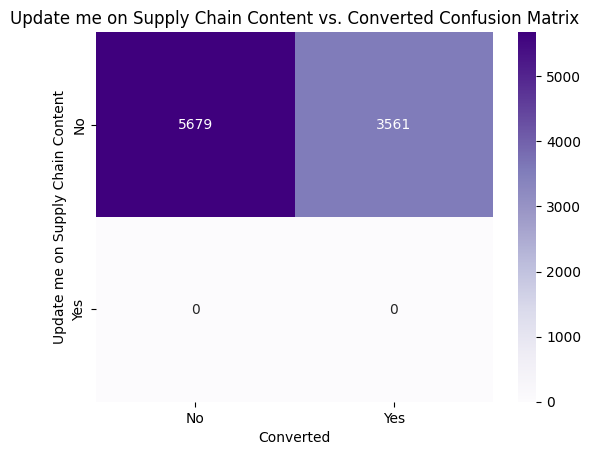

In [165]:
#Plot distribution of Update me on Supply Chain Content by Converted
confusionmatrix_by_converted('Update me on Supply Chain Content')

### Observations

* Not a single lead indicated that they wanted to receive updates on supply chain content.
* Sending out this kind of content to leads is evidently not of interest to them.

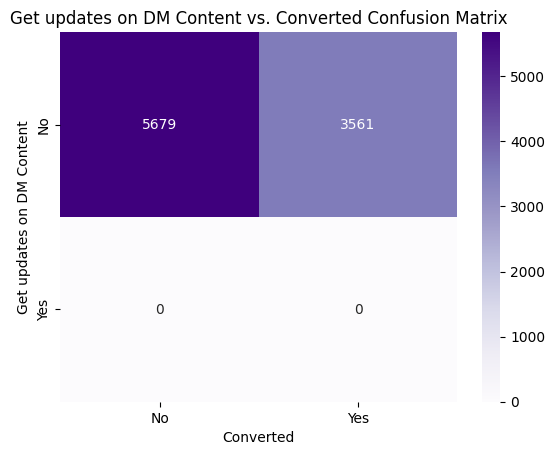

In [166]:
#Plot distribution of Get updates on DM Content by Converted
confusionmatrix_by_converted('Get updates on DM Content')

### Observations

* Not a single lead indicated that they wanted to receive updates on DM content.
* Sending out this kind of content to leads is evidently not of interest to them.

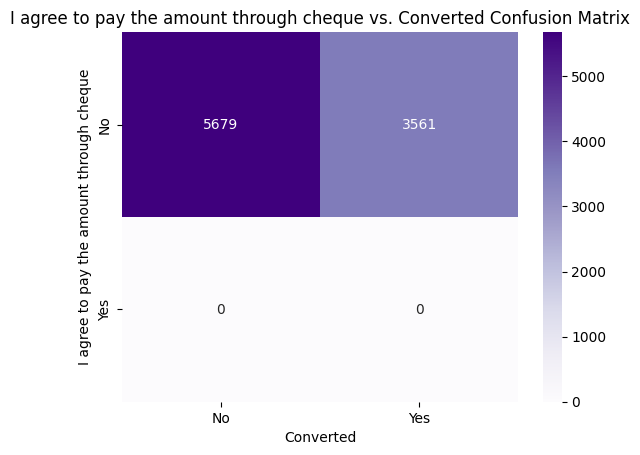

In [167]:
#Plot distribution of I agree to pay the amount through cheque by Converted
confusionmatrix_by_converted('I agree to pay the amount through cheque')

### Observations

* Not a single lead indicated that they wanted to pay by cheque.
* This payment method is evidently not of interest to leads.

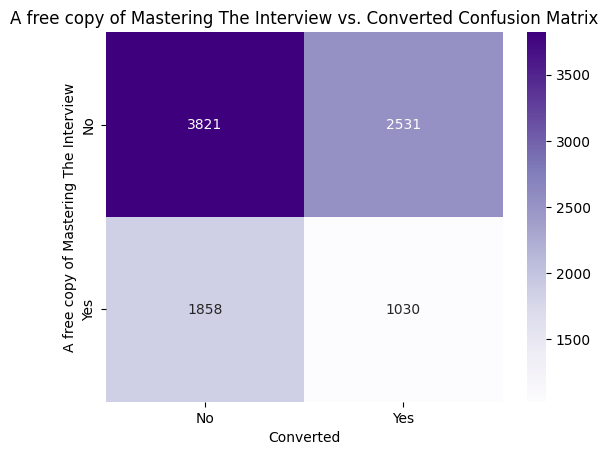

In [168]:
#Plot distribution of A free copy of Mastering The Interview by Converted
confusionmatrix_by_converted('A free copy of Mastering The Interview')

In [169]:
#Compute conversion rate among leads who did and didn't want to receive a free copy of Mastering The Interview
print('The overall lead conversion rate is ', df['Converted'].mean())
print('The lead conversion rate among those who received a free copy of Mastering The Interview is ',df[df['A free copy of Mastering The Interview']==True]['Converted'].mean())
print('The lead conversion rate among those who DID NOT receive a free copy of Mastering The Interview is ',df[df['A free copy of Mastering The Interview']==False]['Converted'].mean())

The overall lead conversion rate is  0.3853896103896104
The lead conversion rate among those who received a free copy of Mastering The Interview is  0.35664819944598336
The lead conversion rate among those who DID NOT receive a free copy of Mastering The Interview is  0.3984571788413098


### Observations

* Nearly 1/3 leads wanted to receive a free copy of Mastering The Interview
* Interestingly, leads who received a free copy of Mastering The Interview had a lower conversion rate!
* **Could this be because once leads receive a copy for Mastering The Interview, they don't feel the need for X Education's courses?**

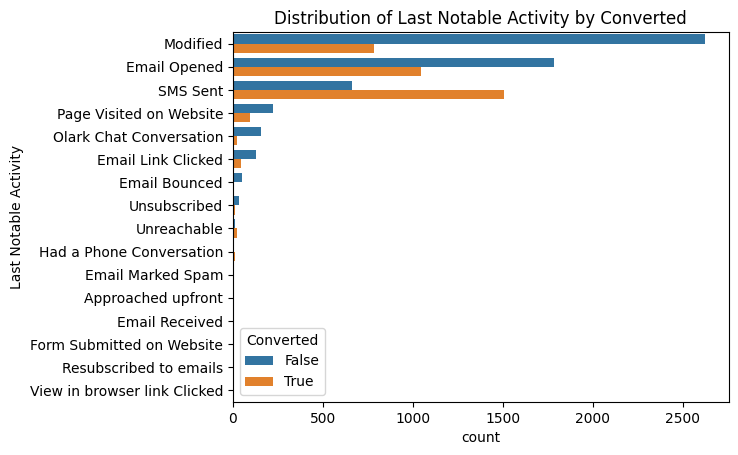

In [170]:
#Plot distribution of Last Notable Activity by Converted
count_by_converted('Last Notable Activity')

### Observations

* As seen under Last Activity, SMS Sent is the Last Notable Activity with the highest conversion rate.

# Creation Model

Data Splitting

We identify model predictors (all remaining dataset features except Lead Number) and the target variable. Categorical variables codified using One-Hot Encoding.

Then, we split our data into a training and a testing set (70% of the data will be used for the training set, while the remaining 30% will be used in the test set).

In [171]:
#Split data into training and testing set
drop_cols = ['Lead Number','Converted']
X = pd.get_dummies(df.drop(columns=drop_cols, axis=1))
y = df['Converted']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=123, stratify=y)

### Feature Scaling
Most classification models perform better after feature scaling. This is because numeric predictors often have different centers and ranges. For this dataset, numeric predictors include the following:

* TotalVisits
* Total Time Spent on Website
* Page Views per Visit

Since none of these features follow a normal distribution, standardization using MinMaxScaler is the prefered feature scaling method.

In [172]:
#Scale the numeric features using MinMaxScaler
scale_cols = ['TotalVisits','Total Time Spent on Website','Page Views Per Visit']
scaler = MinMaxScaler()
X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])
X_test[scale_cols] = scaler.transform(X_test[scale_cols])


### Model Building
Next, we build two models and compare their performance - a Logistic Regression model and a Random Forest Ensemble model.

Both models will be assessed on their AUC value. AUC (Area Under Curve) is an especially useful performance metric for models whose output are a probability. In short, it indicates the percentage of the time a model correctly assigns a higher probability to a lead that will convert when compared to a lead that will not convert. As such, it is valuable in determining the performance of a lead scoring model.

In the Logistic Regression model, the 'liblinear' optimization algorithm is used since it performs well on relatively small datasets. GridSearchCV is used to find the algorithm's optimal regularization strength and penalty norm to maximize model AUC.

In [173]:
#Fit logistic model
parameters_lr = {'penalty': ['l1', 'l2'], 'C' : np.logspace(-3,3,5,base=10.0)}
lr = LogisticRegression(solver='liblinear', random_state=123)

lr_cv = GridSearchCV(lr, param_grid=parameters_lr, cv=5, scoring='roc_auc', n_jobs=-1)
lr_cv.fit(X_train, y_train)

print(lr_cv.best_params_)
lr_best = lr_cv.best_estimator_

{'C': 1.0, 'penalty': 'l1'}


In [174]:
#Fit random forest classifier w/ hyperparameter tuning
parameters_rf = {'max_depth':np.arange(6,30,2),'min_samples_leaf':np.arange(100,500,50)}
rf = RandomForestClassifier()

rf_cv = GridSearchCV(rf, param_grid=parameters_rf, cv=5, scoring='roc_auc', n_jobs=-1)
rf_cv.fit(X_train, y_train)

print(rf_cv.best_params_)
rf_best = rf_cv.best_estimator_

{'max_depth': 14, 'min_samples_leaf': 100}


#### Model Comparison
As outlined previously, AUC is the performance metric by which these models will be compared. We also plot their ROC curves to assess for any major differences in shape.

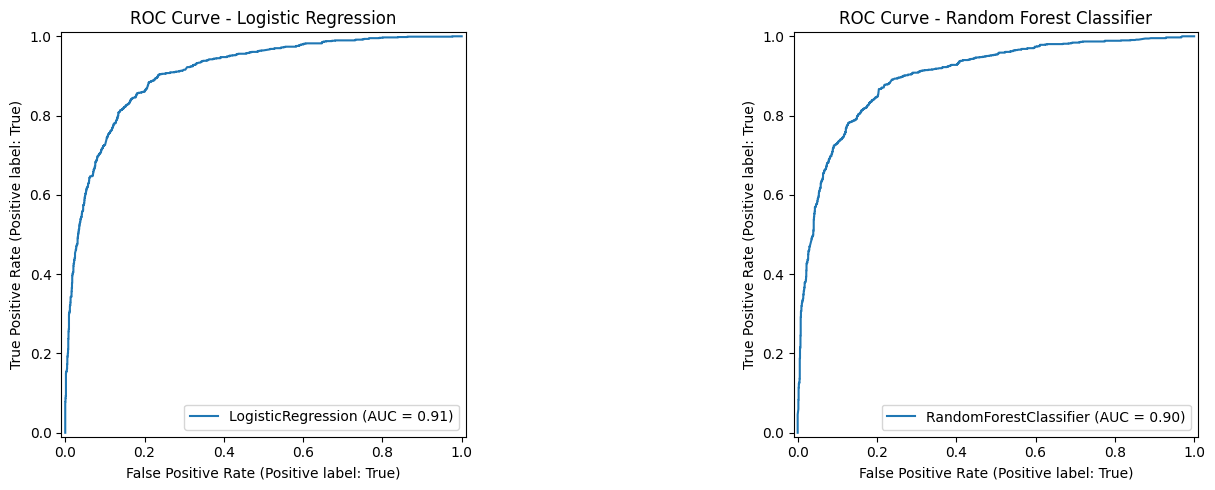

In [175]:
#Plot ROC curve & AUC
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))
models = {'Logistic Regression': lr_best, 'Random Forest Classifier': rf_best}

for n, m in models.items():
    RocCurveDisplay.from_estimator(m, X_test, y_test, ax=axes[list(models.keys()).index(n)])
    axes[list(models.keys()).index(n)].set_title('ROC Curve - ' + n)

plt.tight_layout()
plt.show()


At first glance, the Logistic Regression model appears to perform better. Both models have similar ROC curves, but the Logistic Regression model shows a slightly higher AUC value.

To assess each model's fit, we can compare the AUC score on the training & test sets.

In [176]:
#Compute AUC score on training & test data for the Logistic Regression model
print('Logistic Regression - AUC (training set):', roc_auc_score(y_train, lr_best.predict_proba(X_train)[:,1]))
print('Logistic Regression - AUC (test set):', roc_auc_score(y_test, lr_best.predict_proba(X_test)[:,1]))

Logistic Regression - AUC (training set): 0.9217146374628834
Logistic Regression - AUC (test set): 0.9093719228605089


In [177]:
#Compute AUC score on training & test data for the Random Forest Classifier model
print('Random Forest Classifier - AUC (training set):', roc_auc_score(y_train, rf_best.predict_proba(X_train)[:,1]))
print('Random Forest Classifier - AUC (test set):', roc_auc_score(y_test, rf_best.predict_proba(X_test)[:,1]))

Random Forest Classifier - AUC (training set): 0.9099696508714967
Random Forest Classifier - AUC (test set): 0.9006460344463786


By comparing these AUC scores, we see that neither model overfits the data, as the AUC score on the test sets are only slightly lower. We can also confirm that the Logisitc Regression model is the one that achieves the highest AUC on the test set of 0.9093.

We can further compare how each of these models separate the data by comparing the distribution of the lead scores they assign for converted and non-converted leads.

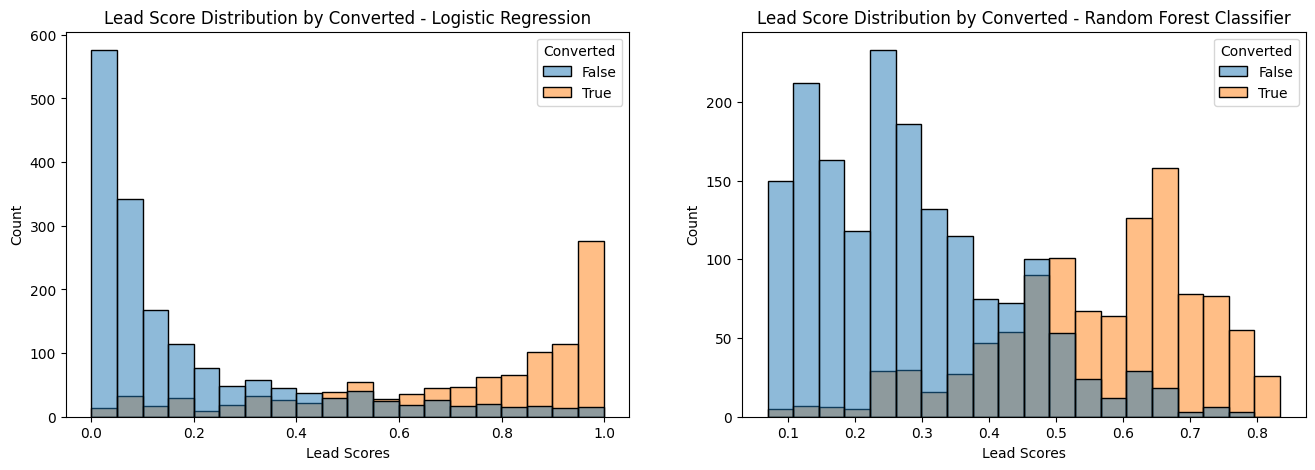

In [178]:
#Plot histogram of lead scores by Converted
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(16, 5))

for n,m in models.items():
    sns.histplot(x=m.predict_proba(X_test)[:,1], hue=y_test, ax=axes[list(models.keys()).index(n)], bins=20)
    plt.sca(axes[list(models.keys()).index(n)])
    plt.title('Lead Score Distribution by Converted - ' + n)
    plt.xlabel('Lead Scores')

The above histograms appear to validate the higher AUC score shown by the Logistic Regression model. The lead scores appear to be more cleanly separated in the Logistic Regression histogram, with less overlap between the scores of converted and non-converted leads.

**As such, we can select the Logistic Regression model as our Lead Scoring Model of choice.**

### Conclusion
In conclusion, the logistic regression model we developed proved to be a superior lead scoring model. In nearly 88% of cases, it correctly assigns a higher lead score to leads that will convert compared to a lead who will not convert. By using this lead scoring model, the sales team can increase their conversion rate to 80% by focussing on the top 30% of leads by lead score.


As a recommended next step for X Education, it would be valuable to determine a minimum lead score for sales reps to bother contacting a lead. This can be done after the cost of having a sales rep contact a lead, as well as the value of a converted lead, has been determined. Using a profit matrix, the optimal threshold for classification to maximize profit can be identified.